In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

[14:14:01] SMILES Parse Error: syntax error while parsing: O[C@H]1[C@H](O)[C@@H](N)[C@@H](O[C@@H]2[C@@H](N)C[C@@H](N)[C@H](O)[C@H]2O[C@@H]3O[C@H](CO)[C@@H](O[C@H]4O[C@@H](CN)[C@@H](O)[C@H](O)[C@H]4N)[C@H]3O)O[C@@H]1CN.[3H2SO4]
[14:14:01] SMILES Parse Error: check for mistakes around position 163:
[14:14:01] @H]3O)O[C@@H]1CN.[3H2SO4]
[14:14:01] ~~~~~~~~~~~~~~~~~~~~^
[14:14:01] SMILES Parse Error: Failed parsing SMILES 'O[C@H]1[C@H](O)[C@@H](N)[C@@H](O[C@@H]2[C@@H](N)C[C@@H](N)[C@H](O)[C@H]2O[C@@H]3O[C@H](CO)[C@@H](O[C@H]4O[C@@H](CN)[C@@H](O)[C@H](O)[C@H]4N)[C@H]3O)O[C@@H]1CN.[3H2SO4]' for input: 'O[C@H]1[C@H](O)[C@@H](N)[C@@H](O[C@@H]2[C@@H](N)C[C@@H](N)[C@H](O)[C@H]2O[C@@H]3O[C@H](CO)[C@@H](O[C@H]4O[C@@H](CN)[C@@H](O)[C@H](O)[C@H]4N)[C@H]3O)O[C@@H]1CN.[3H2SO4]'
[14:14:02] SMILES Parse Error: syntax error while parsing: O=S([O-])(CCNC(CC[C@@H](C)[C@H]1CC[C@@]2([H])[C@]3([H])CC[C@]4([H])C[C@H](O)CC[C@]4(C)[C@@]3([H])C[C@H](O)[C@]12C)=O)=O.[Na+].[x
[14:14:02] SMILES Parse Error: check for

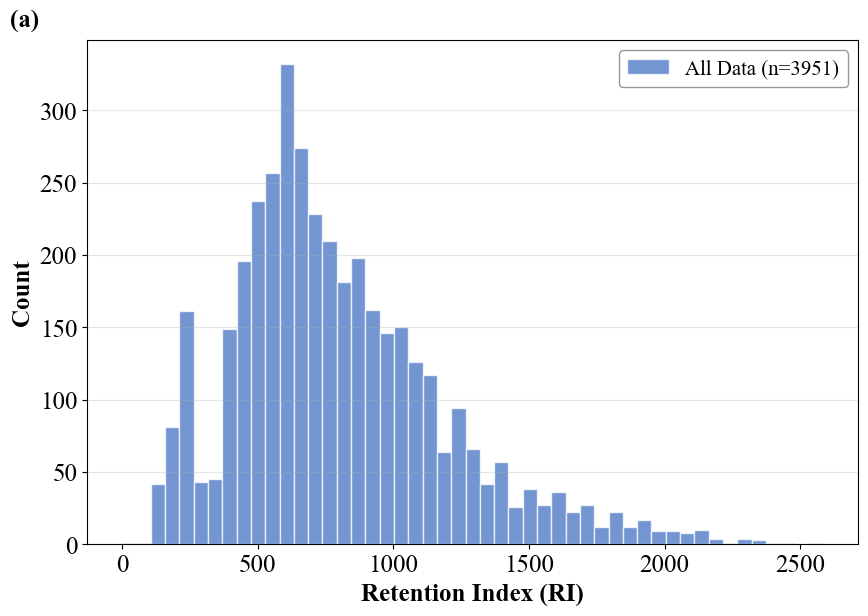

Done! -> /Users/wangxujie/Desktop/GNN-Multi-v2/figure_a.png


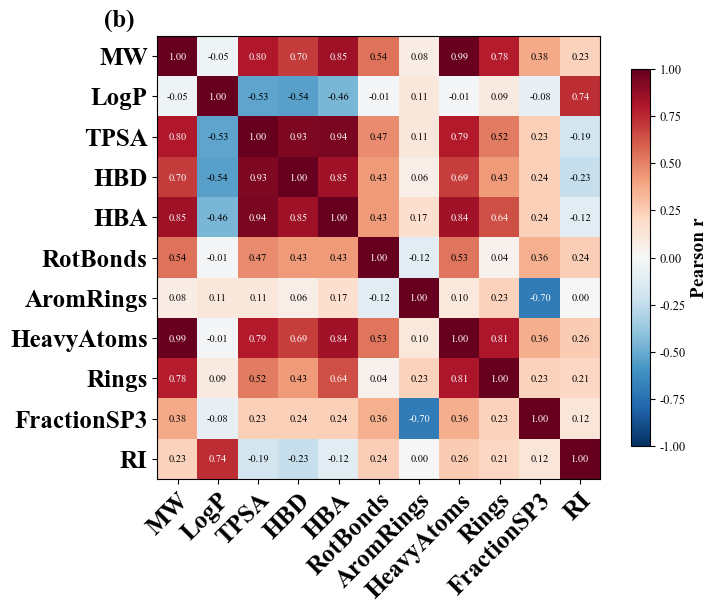

Done! -> /Users/wangxujie/Desktop/GNN-Multi-v2/figure_b.png


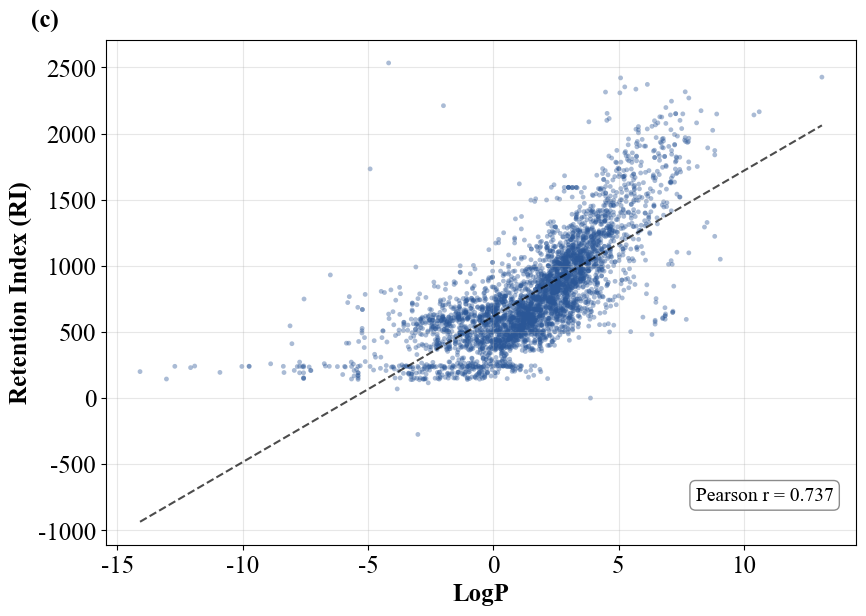

Done! -> /Users/wangxujie/Desktop/GNN-Multi-v2/figure_c.png


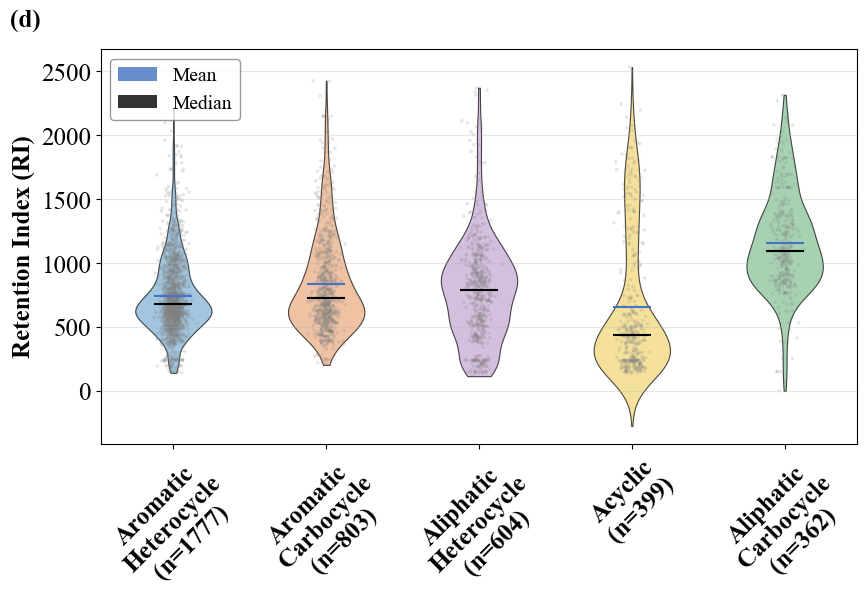

Done! -> /Users/wangxujie/Desktop/GNN-Multi-v2/figure_d.png


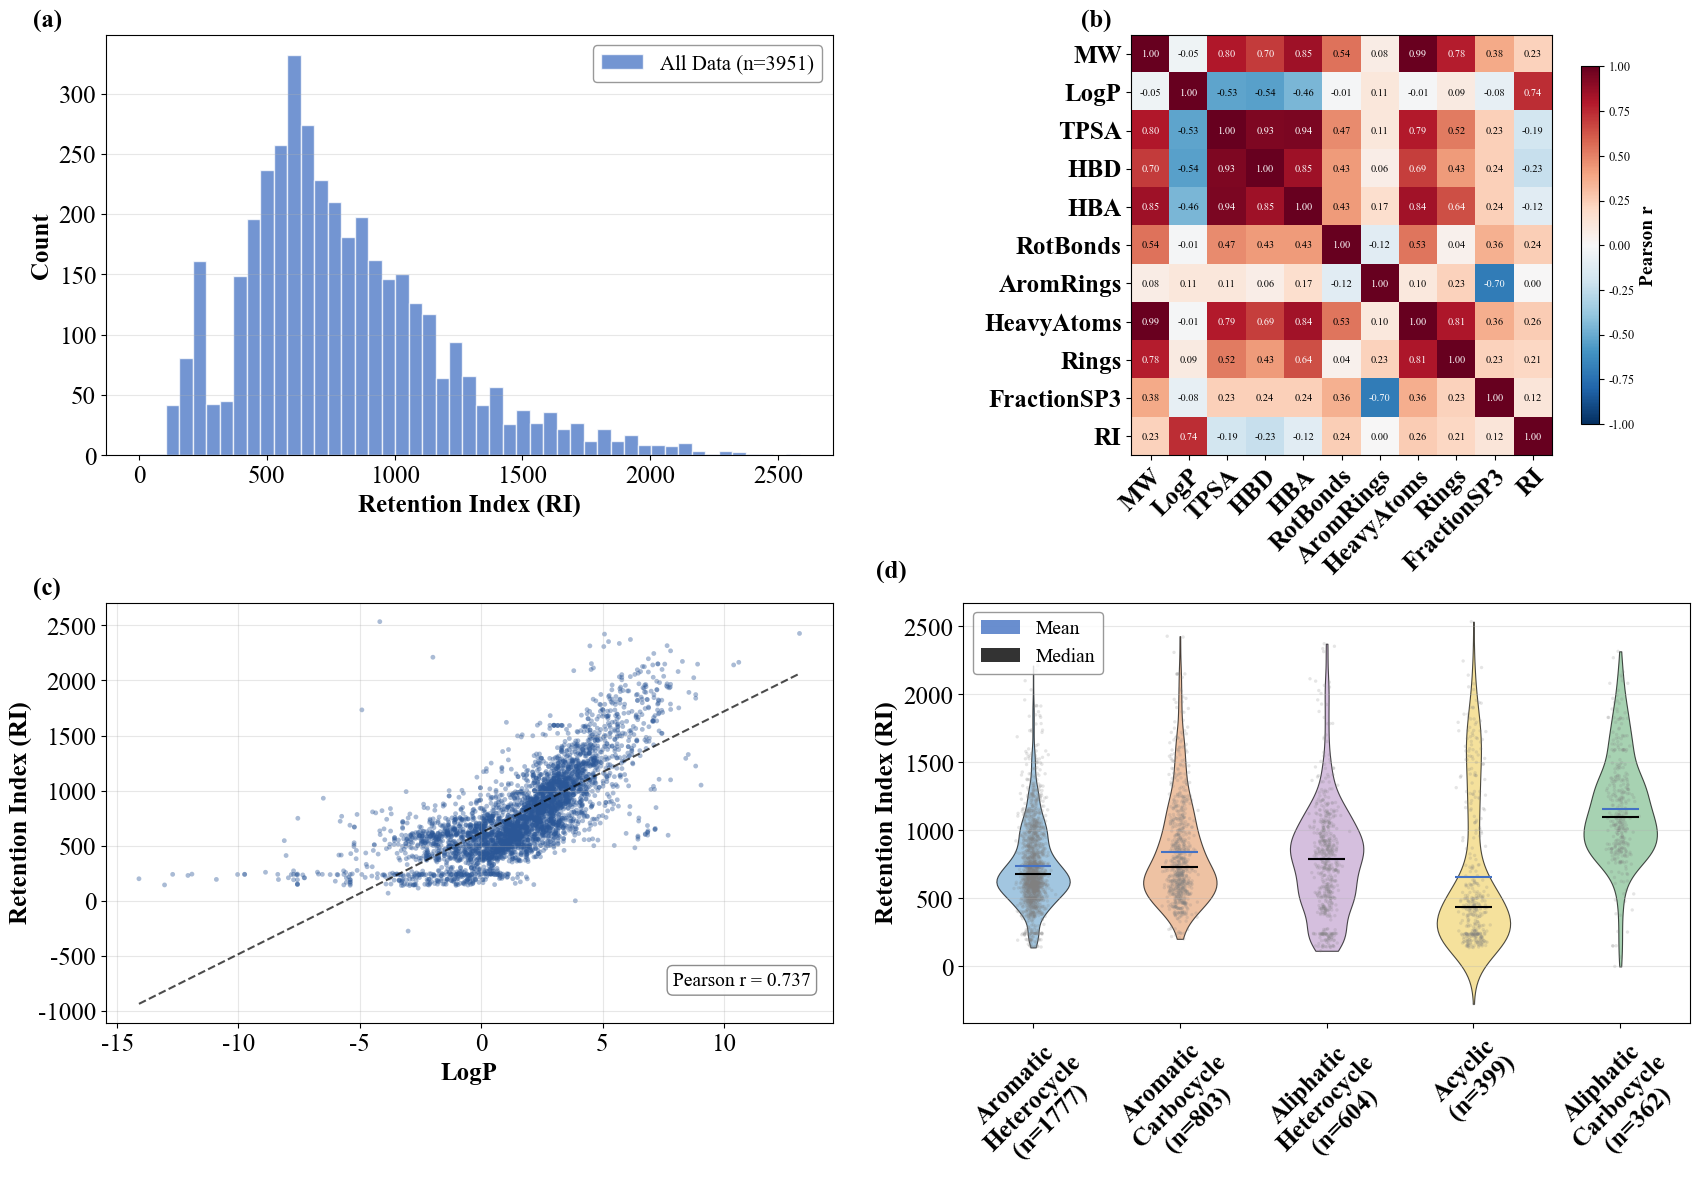

Done! -> /Users/wangxujie/Desktop/GNN-Multi-v2/combined_figure.png


In [3]:

# ========================================================
# 项目根目录（所有路径均使用绝对路径）
# ========================================================
BASE_DIR = '/Users/wangxujie/Desktop/GNN-Multi-v2'

# ========================================================
# 全局字体设置：Times New Roman
# ========================================================
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['font.size'] = 18
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['mathtext.fontset'] = 'stix'


# ========================================================
# 数据读取与预处理
# ========================================================
def load_and_prepare(data_dir=BASE_DIR + '/data'):
    """读取 train/test 数据，计算分子描述符与化合物分类。"""
    train = pd.read_table(os.path.join(data_dir, 'train_set_stratified.txt'))
    test = pd.read_table(os.path.join(data_dir, 'test_set_stratified.txt'))
    all_data = pd.concat([train, test], ignore_index=True)

    valid_mols = []
    valid_idx = []
    for i, smi in enumerate(all_data['smiles']):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            valid_mols.append(mol)
            valid_idx.append(i)
    valid_data = all_data.iloc[valid_idx].reset_index(drop=True)

    properties = {
        'MW':          [Descriptors.MolWt(m)             for m in valid_mols],
        'LogP':        [Crippen.MolLogP(m)               for m in valid_mols],
        'TPSA':        [Descriptors.TPSA(m)              for m in valid_mols],
        'HBD':         [Lipinski.NumHDonors(m)           for m in valid_mols],
        'HBA':         [Lipinski.NumHAcceptors(m)        for m in valid_mols],
        'RotBonds':    [Descriptors.NumRotatableBonds(m)  for m in valid_mols],
        'AromRings':   [rdMolDescriptors.CalcNumAromaticRings(m) for m in valid_mols],
        'HeavyAtoms':  [m.GetNumHeavyAtoms()             for m in valid_mols],
        'Rings':       [rdMolDescriptors.CalcNumRings(m)  for m in valid_mols],
        'FractionSP3': [rdMolDescriptors.CalcFractionCSP3(m) for m in valid_mols],
    }
    ri_values = valid_data['RT'].values
    prop_df = pd.DataFrame(properties)
    prop_df['RI'] = ri_values

    corr = prop_df.corr()
    ri_corr = corr['RI'].drop('RI').sort_values(key=abs, ascending=False)
    logp_r = ri_corr['LogP']

    categories = [classify_compound(m) for m in valid_mols]
    cat_counts = Counter(categories)
    order = [c for c, _ in cat_counts.most_common()]

    return {
        'all_data': all_data,
        'valid_data': valid_data,
        'valid_mols': valid_mols,
        'prop_df': prop_df,
        'corr': corr,
        'logp_r': logp_r,
        'categories': categories,
        'cat_counts': cat_counts,
        'order': order,
    }


def classify_compound(mol):
    """根据环类型对化合物进行分类。"""
    n_rings = rdMolDescriptors.CalcNumRings(mol)
    n_arom = rdMolDescriptors.CalcNumAromaticRings(mol)
    n_aliph = rdMolDescriptors.CalcNumAliphaticRings(mol)
    n_hetero = rdMolDescriptors.CalcNumHeterocycles(mol)
    if n_rings == 0:
        return 'Acyclic'
    if n_arom == 0 and n_aliph > 0 and n_hetero == 0:
        return 'Aliphatic\nCarbocycle'
    if n_arom > 0 and n_hetero == 0:
        return 'Aromatic\nCarbocycle'
    if n_hetero > 0 and n_arom == 0:
        return 'Aliphatic\nHeterocycle'
    if n_hetero > 0 and n_arom > 0:
        return 'Aromatic\nHeterocycle'
    return 'Other'


# ========================================================
# 子图 a：RI 分布直方图
# ========================================================
def plot_figure_a(data, save_path=BASE_DIR + '/figure_a.png'):
    fig, ax = plt.subplots(figsize=(9, 6.5))

    bins = np.linspace(0, data['all_data']['RT'].max() + 50, 50)
    ax.hist(data['all_data']['RT'], bins=bins, color='#4472C4', alpha=0.75,
            edgecolor='white', label=f'All Data (n={len(data["all_data"])})')

    ax.set_xlabel('Retention Index (RI)', fontsize=18, fontweight='bold')
    ax.set_ylabel('Count', fontsize=18, fontweight='bold')
    ax.legend(fontsize=15, frameon=True, edgecolor='gray', loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='both', labelsize=18)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Times New Roman')

    ax.text(-0.10, 1.06, '(a)', transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', ha='left',
            fontname='Times New Roman')

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)
    print(f'Done! -> {save_path}')


# ========================================================
# 子图 b：分子性质相关性热图
# ========================================================
def plot_figure_b(data, save_path=BASE_DIR + '/figure_b.png'):
    fig, ax = plt.subplots(figsize=(9, 6.5))

    corr_mat = data['prop_df'].corr()
    labels = list(corr_mat.columns)
    im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', rotation_mode='anchor',
                       fontsize=18, fontweight='bold')
    ax.set_yticklabels(labels, fontsize=18, fontweight='bold')

    for i in range(len(labels)):
        for j in range(len(labels)):
            val = corr_mat.values[i, j]
            color = 'white' if abs(val) > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7.5, color=color)

    cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.04)
    cbar.set_label('Pearson r', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=9)
    for label in cbar.ax.get_yticklabels():
        label.set_fontname('Times New Roman')

    ax.tick_params(axis='both', labelsize=18)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Times New Roman')

    ax.text(-0.12, 1.06, '(b)', transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', ha='left',
            fontname='Times New Roman')

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)
    print(f'Done! -> {save_path}')


# ========================================================
# 子图 c：LogP vs RI 散点图
# ========================================================
def plot_figure_c(data, save_path=BASE_DIR + '/figure_c.png'):
    fig, ax = plt.subplots(figsize=(9, 6.5))

    x = data['prop_df']['LogP'].values
    y = data['prop_df']['RI'].values
    ax.scatter(x, y, c='#2B5797', alpha=0.4, s=12, edgecolor='none')

    if np.std(x) > 0:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, p(xs), 'k--', linewidth=1.5, alpha=0.7)

    ax.set_xlabel('LogP', fontsize=18, fontweight='bold')
    ax.set_ylabel('Retention Index (RI)', fontsize=18, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', labelsize=18)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Times New Roman')

    ax.text(0.97, 0.08, f'Pearson r = {data["logp_r"]:.3f}',
            transform=ax.transAxes, fontsize=14, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.9))

    ax.text(-0.10, 1.06, '(c)', transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', ha='left',
            fontname='Times New Roman')

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)
    print(f'Done! -> {save_path}')


# ========================================================
# 子图 d：按化合物类型分组的 RI 小提琴图
# ========================================================
def plot_figure_d(data, save_path=BASE_DIR + '/figure_d.png'):
    fig, ax = plt.subplots(figsize=(9, 6.5))

    categories = data['categories']
    valid_data = data['valid_data']
    order = data['order']
    cat_counts = data['cat_counts']

    data_by_cat = [valid_data.loc[[categories[i] == c for i in range(len(categories))], 'RT'].values
                   for c in order]
    parts = ax.violinplot(data_by_cat, positions=range(len(order)),
                          showmeans=True, showmedians=True, showextrema=False)

    violin_colors = ['#7BAFD4', '#E8A87C', '#C4A5D0', '#F2D572', '#82C092']
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(violin_colors[i % len(violin_colors)])
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.8)

    parts['cmeans'].set_color('#4472C4')
    parts['cmeans'].set_linewidth(1.5)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)

    np.random.seed(42)
    for i, vals in enumerate(data_by_cat):
        jitter = np.random.normal(i, 0.04, size=len(vals))
        ax.scatter(jitter, vals, alpha=0.2, s=6, c='gray', edgecolor='none')

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f'{c}\n(n={cat_counts[c]})' for c in order],
                       fontsize=18, rotation=45, ha='center', fontweight='bold')
    ax.set_ylabel('Retention Index (RI)', fontsize=18, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='both', labelsize=18)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Times New Roman')

    legend_elements = [Patch(facecolor='#4472C4', alpha=0.8, label='Mean'),
                       Patch(facecolor='black', alpha=0.8, label='Median')]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=14,
              frameon=True, edgecolor='gray')

    ax.text(-0.12, 1.10, '(d)', transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', ha='left',
            fontname='Times New Roman')

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)
    print(f'Done! -> {save_path}')


# ========================================================
# 组合图：2×2 布局
# ========================================================
def plot_combined(data, save_path=BASE_DIR + '/combined_figure.png'):
    fig = plt.figure(figsize=(18, 13))
    gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.18,
                          left=0.08, right=0.96, top=0.92, bottom=0.16,
                          height_ratios=[1, 1])

    # ---------- (a) ----------
    ax_a = fig.add_subplot(gs[0, 0])
    bins = np.linspace(0, data['all_data']['RT'].max() + 50, 50)
    ax_a.hist(data['all_data']['RT'], bins=bins, color='#4472C4', alpha=0.75,
              edgecolor='white', label=f'All Data (n={len(data["all_data"])})')
    ax_a.set_xlabel('Retention Index (RI)', fontsize=18, fontweight='bold')
    ax_a.set_ylabel('Count', fontsize=18, fontweight='bold')
    ax_a.legend(fontsize=15, frameon=True, edgecolor='gray', loc='upper right')
    ax_a.grid(axis='y', alpha=0.3)
    ax_a.tick_params(axis='both', labelsize=18)
    for label in ax_a.get_xticklabels() + ax_a.get_yticklabels():
        label.set_fontname('Times New Roman')

    # ---------- (b) ----------
    ax_b = fig.add_subplot(gs[0, 1])
    corr_mat = data['prop_df'].corr()
    labels = list(corr_mat.columns)
    im = ax_b.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
    ax_b.set_xticks(range(len(labels)))
    ax_b.set_yticks(range(len(labels)))
    ax_b.set_xticklabels(labels, rotation=45, ha='right', rotation_mode='anchor',
                         fontsize=18, fontweight='bold')
    ax_b.set_yticklabels(labels, fontsize=18, fontweight='bold')
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = corr_mat.values[i, j]
            color = 'white' if abs(val) > 0.6 else 'black'
            ax_b.text(j, i, f'{val:.2f}', ha='center', va='center',
                      fontsize=7.5, color=color)
    cbar = plt.colorbar(im, ax=ax_b, shrink=0.85, pad=0.04)
    cbar.set_label('Pearson r', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=9)
    for label in cbar.ax.get_yticklabels():
        label.set_fontname('Times New Roman')

    # ---------- (c) ----------
    ax_c = fig.add_subplot(gs[1, 0])
    x = data['prop_df']['LogP'].values
    y = data['prop_df']['RI'].values
    ax_c.scatter(x, y, c='#2B5797', alpha=0.4, s=12, edgecolor='none')
    if np.std(x) > 0:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        xs = np.linspace(x.min(), x.max(), 100)
        ax_c.plot(xs, p(xs), 'k--', linewidth=1.5, alpha=0.7)
    ax_c.set_xlabel('LogP', fontsize=18, fontweight='bold')
    ax_c.set_ylabel('Retention Index (RI)', fontsize=18, fontweight='bold')
    ax_c.grid(alpha=0.3)
    ax_c.tick_params(axis='both', labelsize=18)
    for label in ax_c.get_xticklabels() + ax_c.get_yticklabels():
        label.set_fontname('Times New Roman')
    ax_c.text(0.97, 0.08, f'Pearson r = {data["logp_r"]:.3f}',
              transform=ax_c.transAxes, fontsize=14, ha='right', va='bottom',
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.9))

    # ---------- (d) ----------
    ax_d = fig.add_subplot(gs[1, 1])
    categories = data['categories']
    valid_data = data['valid_data']
    order = data['order']
    cat_counts = data['cat_counts']

    data_by_cat = [valid_data.loc[[categories[i] == c for i in range(len(categories))], 'RT'].values
                   for c in order]
    parts = ax_d.violinplot(data_by_cat, positions=range(len(order)),
                            showmeans=True, showmedians=True, showextrema=False)
    violin_colors = ['#7BAFD4', '#E8A87C', '#C4A5D0', '#F2D572', '#82C092']
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(violin_colors[i % len(violin_colors)])
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.8)
    parts['cmeans'].set_color('#4472C4')
    parts['cmeans'].set_linewidth(1.5)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)

    np.random.seed(42)
    for i, vals in enumerate(data_by_cat):
        jitter = np.random.normal(i, 0.04, size=len(vals))
        ax_d.scatter(jitter, vals, alpha=0.2, s=6, c='gray', edgecolor='none')

    ax_d.set_xticks(range(len(order)))
    ax_d.set_xticklabels([f'{c}\n(n={cat_counts[c]})' for c in order],
                         fontsize=18, rotation=45, ha='center', fontweight='bold')
    ax_d.set_ylabel('Retention Index (RI)', fontsize=18, fontweight='bold')
    ax_d.grid(axis='y', alpha=0.3)
    ax_d.tick_params(axis='both', labelsize=18)
    for label in ax_d.get_xticklabels() + ax_d.get_yticklabels():
        label.set_fontname('Times New Roman')

    legend_elements = [Patch(facecolor='#4472C4', alpha=0.8, label='Mean'),
                       Patch(facecolor='black', alpha=0.8, label='Median')]
    ax_d.legend(handles=legend_elements, loc='upper left', fontsize=14,
                frameon=True, edgecolor='gray')

    # ---------- 子图标注 ----------
    label_props = dict(fontsize=18, fontweight='bold', va='top', ha='left',
                       fontname='Times New Roman')
    ax_a.text(-0.10, 1.06, '(a)', transform=ax_a.transAxes, **label_props)
    ax_b.text(-0.12, 1.06, '(b)', transform=ax_b.transAxes, **label_props)
    ax_c.text(-0.10, 1.06, '(c)', transform=ax_c.transAxes, **label_props)
    ax_d.text(-0.12, 1.10, '(d)', transform=ax_d.transAxes, **label_props)

    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()
    print(f'Done! -> {save_path}')


# ========================================================
# 主入口
# ========================================================
if __name__ == '__main__':
    data = load_and_prepare(data_dir=BASE_DIR + '/data')

    # 单独生成四个子图
    plot_figure_a(data, save_path=BASE_DIR + '/figure_a.png')
    plot_figure_b(data, save_path=BASE_DIR + '/figure_b.png')
    plot_figure_c(data, save_path=BASE_DIR + '/figure_c.png')
    plot_figure_d(data, save_path=BASE_DIR + '/figure_d.png')

    # 生成完整组合图
    plot_combined(data, save_path=BASE_DIR + '/combined_figure.png')
